# Importing Libraries

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam


In [ ]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset Path

In [ ]:
# 3. Dataset paths
base_path = "/content/drive/MyDrive/Colab dataset/data"
train_dir = os.path.join(base_path, "training")
test_dir = os.path.join(base_path, "test")


# Loading the Image

In [ ]:
# 4. Image loading function (label based on 'genuine' or 'forged' in filename)
def load_images_and_labels(data_dir):
    images = []
    labels = []
    for user_folder in os.listdir(data_dir):
        user_path = os.path.join(data_dir, user_folder)
        if not os.path.isdir(user_path):
            continue
        for filename in os.listdir(user_path):
            file_path = os.path.join(user_path, filename)
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Failed to load {file_path}")
                continue
            img = cv2.resize(img, (150, 150))
            images.append(img)

            # Label: 1 for genuine, 0 for forged
            filename_lower = filename.lower()
            if "forged" in filename_lower:
                labels.append(0)
            elif "genuine" in filename_lower:
                labels.append(1)
            else:
                print(f"Unknown label for {filename}, skipping...")
                continue
    return images, labels

# Loading the Dataset

In [ ]:
# 5. Load data
train_imgs, train_labels = load_images_and_labels(train_dir)
test_imgs, test_labels = load_images_and_labels(test_dir)

# Combine both for full training
all_imgs = train_imgs + test_imgs
all_labels = train_labels + test_labels

# Preprocessing the Data

In [ ]:
# 6. Preprocess data
X = np.array(all_imgs).reshape(-1, 150, 150, 1) / 255.0
y = to_categorical(all_labels, num_classes=2)

print(f"Loaded {X.shape[0]} images.")

Loaded 143 images.


# Splitting the Data

In [ ]:
# 7. Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Creation

In [ ]:
# 8. CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# Training the Model

In [ ]:
# 9. Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=16)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 4.3363e-05 - val_accuracy: 1.0000 - val_loss: 0.0324
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 2.3514e-05 - val_accuracy: 1.0000 - val_loss: 0.0373
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 4.5055e-04 - val_accuracy: 0.9310 - val_loss: 0.0569
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 3.1236e-05 - val_accuracy: 0.9310 - val_loss: 0.1059
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 9.1178e-06 - val_accuracy: 0.9310 - val_loss: 0.1323
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 6.5368e-04 - val_accuracy: 0.9310 - val_loss: 0.0758
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 6.7159e-06 - val_accuracy: 0.9310 - val_loss: 0.0577
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 1.0178e-05 - val_accu

# Graph Plotting

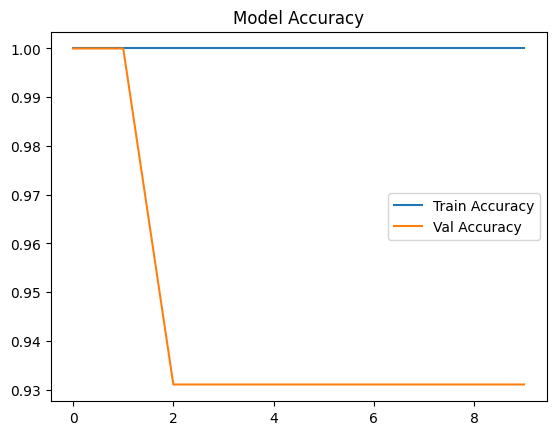

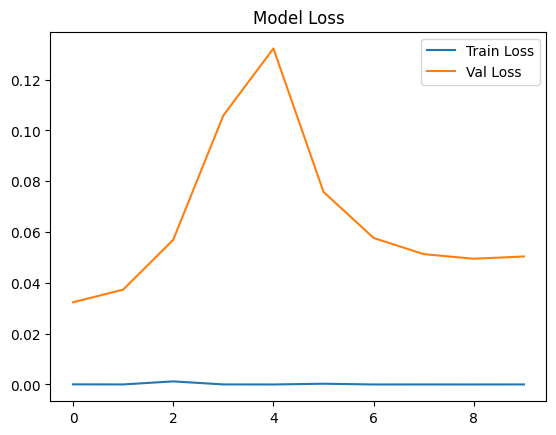

In [ ]:
# 10. Plot accuracy and loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()


In [ ]:
# 11. Save the model
model.save("/content/drive/MyDrive/Colab Notebooks/signature_model.keras")

# Accuracy

In [ ]:
# Get Final Training and Validation Accuracy
final_train_acc = history.history['accuracy'][-1]  # Last epoch training accuracy
final_val_acc = history.history['val_accuracy'][-1]  # Last epoch validation accuracy

print(f"Last Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Last Testing Accuracy: {final_val_acc * 100:.2f}%")


Last Training Accuracy: 100.00%
Last Testing Accuracy: 93.10%


In [ ]:
!md5sum "/content/drive/MyDrive/Colab Notebooks/signature_model.keras"


37ec3fd622d641a41f723294bd17cdf9  /content/drive/MyDrive/Colab Notebooks/signature_model.keras


In [ ]:
model_EfficientNetB2 = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/signature_model.keras")


# Prediction of Signatures

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction (Genuine): 0.00%
Prediction (Forged): 100.00%


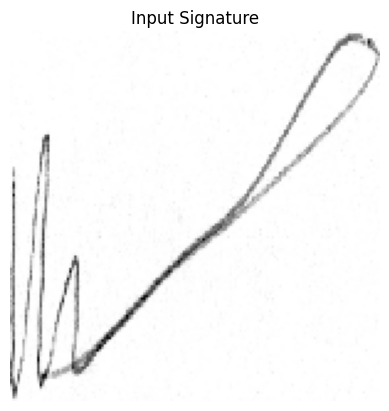

Prediction: Forged Signature (Confidence: 100.00%)


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def predict_signature(image_path, model):
    # Load and preprocess the image
    image = load_img(image_path, target_size=(150, 150), color_mode='grayscale')  # Match input size and color mode (grayscale)
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension
    image_array = image_array / 255.0  # Normalize if needed

    # Make a prediction
    prediction = model.predict(image_array)[0]  # Get the probability scores for both classes (genuine, forged)
    genuine_prob = prediction[1]  # Probability of genuine signature (class 1)
    forged_prob = prediction[0]   # Probability of forged signature (class 0)

    print(f"Prediction (Genuine): {genuine_prob * 100:.2f}%")
    print(f"Prediction (Forged): {forged_prob * 100:.2f}%")

    # Display the image
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title("Input Signature")
    plt.show()

    # Interpret the result with confidence score
    if genuine_prob > forged_prob:
        print(f"Prediction: Genuine Signature (Confidence: {genuine_prob * 100:.2f}%)")
    else:
        print(f"Prediction: Forged Signature (Confidence: {forged_prob * 100:.2f}%)")

# Example usage:
image_path = "/content/drive/MyDrive/Colab dataset/data/test/024/forged-07.png"  # Change path for testing
predict_signature(image_path, model_EfficientNetB2)  # Assuming model_EfficientNetB2 is already loaded
